In [22]:
# !pip install yfinance scikit-learn xgboost tensorflow scipy

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import spearmanr

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
tf.random.set_seed(42)

In [23]:
tickers = ["SPY", "QQQ", "IWM", "EFA", "EEM", "TLT", "GLD", "VNQ"]

start_date = "2010-01-01"
end_date = None

rebalance_freq = "M"
forward_horizon = 21
train_years = 5

top_n = 3
max_weight = 0.40
min_weight = 0.00
transaction_cost_bps = 5

sequence_length = 20
risk_aversion_floor = 0.005

In [24]:
px = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)["Close"]

px = px.dropna(how="all")
px = px.ffill().dropna()

returns = px.pct_change().dropna()

print(px.head())
print(px.shape)

Ticker            EEM        EFA         GLD        IWM        QQQ        SPY  \
Date                                                                            
2010-01-04  30.351515  35.128437  109.800003  51.366562  40.290802  84.796394   
2010-01-05  30.571806  35.159401  109.699997  51.189930  40.290802  85.020866   
2010-01-06  30.635763  35.308006  111.510002  51.141762  40.047760  85.080696   
2010-01-07  30.458107  35.171780  110.820000  51.519104  40.073799  85.439819   
2010-01-08  30.699724  35.450436  111.370003  51.800110  40.403648  85.724182   

Ticker            TLT        VNQ  
Date                              
2010-01-04  55.928650  23.552090  
2010-01-05  56.289864  23.525665  
2010-01-06  55.536304  23.483366  
2010-01-07  55.629700  23.737139  
2010-01-08  55.604847  23.562662  
(4107, 8)


In [25]:
def make_features(px):
    rets = px.pct_change()
    rows = []

    for ticker in px.columns:
        df = pd.DataFrame(index=px.index)
        df["date"] = px.index
        df["ticker"] = ticker
        df["price"] = px[ticker]
        df["ret_1d"] = rets[ticker]

        df["mom_5"] = px[ticker].pct_change(5)
        df["mom_21"] = px[ticker].pct_change(21)
        df["mom_63"] = px[ticker].pct_change(63)

        df["vol_21"] = rets[ticker].rolling(21).std()
        df["vol_63"] = rets[ticker].rolling(63).std()

        df["skew_21"] = rets[ticker].rolling(21).skew()

        downside = rets[ticker].where(rets[ticker] < 0, 0)
        df["downside_vol_21"] = downside.rolling(21).std()

        ma_21 = px[ticker].rolling(21).mean()
        ma_63 = px[ticker].rolling(63).mean()

        df["ma_gap_21"] = px[ticker] / ma_21 - 1
        df["ma_gap_63"] = px[ticker] / ma_63 - 1

        rolling_mean = rets[ticker].rolling(21).mean()
        rolling_std = rets[ticker].rolling(21).std()
        df["zscore_21"] = (rets[ticker] - rolling_mean) / rolling_std

        df["fwd_ret"] = px[ticker].shift(-forward_horizon) / px[ticker] - 1
        df["fwd_vol"] = rets[ticker].rolling(forward_horizon).std().shift(-forward_horizon)

        rows.append(df)

    panel = pd.concat(rows, ignore_index=True)
    return panel


panel = make_features(px)

feature_cols = [
    "ret_1d", "mom_5", "mom_21", "mom_63",
    "vol_21", "vol_63", "skew_21",
    "downside_vol_21", "ma_gap_21", "ma_gap_63",
    "zscore_21"
]

panel = panel.dropna(subset=feature_cols + ["fwd_ret", "fwd_vol"]).copy()
panel["date"] = pd.to_datetime(panel["date"])

print(panel.head())
print(panel.shape)

         date ticker      price    ret_1d     mom_5    mom_21    mom_63  \
63 2010-04-06    EEM  31.083475  0.002981  0.045411  0.068132  0.024116   
64 2010-04-07    EEM  30.813427 -0.008688  0.032381  0.058077  0.007903   
65 2010-04-08    EEM  30.920012  0.003459  0.033001  0.055811  0.009278   
66 2010-04-09    EEM  31.111895  0.006206  0.012957  0.054940  0.021465   
67 2010-04-12    EEM  30.863176 -0.007994 -0.004127  0.046254  0.005324   

      vol_21    vol_63   skew_21  downside_vol_21  ma_gap_21  ma_gap_63  \
63  0.009684  0.014693  0.241598         0.004501   0.047701   0.077488   
64  0.010016  0.014711  0.275676         0.004673   0.035787   0.067985   
65  0.009996  0.014715  0.310047         0.004673   0.036657   0.071511   
66  0.009980  0.014713  0.322547         0.004673   0.040399   0.077773   
67  0.010235  0.014719  0.365508         0.004764   0.029844   0.069061   

    zscore_21   fwd_ret   fwd_vol  
63  -0.021339 -0.094422  0.016276  
64  -1.140873 -0.123847  0

In [26]:
lstm_feature_cols = [
    "ret_1d", "mom_5", "mom_21",
    "vol_21", "vol_63",
    "downside_vol_21", "zscore_21"
]


def build_lstm_dataset(panel, feature_list, target_col, seq_len):
    X, y, meta = [], [], []

    for ticker, g in panel.groupby("ticker"):
        g = g.sort_values("date").reset_index(drop=True)

        X_raw = g[feature_list].values
        y_raw = g[target_col].values
        dates = g["date"].values

        for i in range(seq_len, len(g)):
            X_seq = X_raw[i-seq_len:i]
            y_val = y_raw[i]

            if np.any(pd.isna(X_seq)) or pd.isna(y_val):
                continue

            X.append(X_seq)
            y.append(y_val)
            meta.append((dates[i], ticker))

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    meta = pd.DataFrame(meta, columns=["date", "ticker"])
    meta["date"] = pd.to_datetime(meta["date"])

    return X, y, meta


X_lstm_all, y_lstm_all, meta_lstm = build_lstm_dataset(
    panel,
    lstm_feature_cols,
    "fwd_vol",
    sequence_length
)

print(X_lstm_all.shape, y_lstm_all.shape)

(32024, 20, 7) (32024,)


In [27]:
def rank_ic(y_true, y_pred):
    mask = np.isfinite(y_true) & np.isfinite(y_pred)

    if mask.sum() < 3:
        return np.nan

    return spearmanr(y_true[mask], y_pred[mask]).correlation


def make_lstm_model(input_shape):
    model = Sequential([
        LSTM(32, input_shape=input_shape),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(1)
    ])

    model.compile(optimizer="adam", loss="mse")
    return model


def clip_and_normalize(weights, min_w=0.0, max_w=0.40):
    weights = np.nan_to_num(weights, nan=0.0, posinf=0.0, neginf=0.0)
    weights = np.clip(weights, min_w, max_w)

    total = weights.sum()

    if total <= 0:
        return np.repeat(1 / len(weights), len(weights))

    return weights / total


def perf_stats(r, freq=12):
    r = pd.Series(r).dropna()

    ann_ret = (1 + r).prod() ** (freq / len(r)) - 1
    ann_vol = r.std() * np.sqrt(freq)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan

    cum = (1 + r).cumprod()
    dd = cum / cum.cummax() - 1

    return {
        "Annual Return": ann_ret,
        "Annual Vol": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": dd.min(),
        "Hit Rate": (r > 0).mean()
    }

In [28]:
month_ends = px.resample(rebalance_freq).last().index
available_dates = set(pd.to_datetime(panel["date"].unique()))

month_ends = [d for d in month_ends if d in available_dates]

start_rebalance = month_ends[0] + pd.DateOffset(years=train_years)
rebalance_dates = [d for d in month_ends if d >= start_rebalance]

print("Number of rebalance dates:", len(rebalance_dates))
print("First rebalance date:", rebalance_dates[0])

Number of rebalance dates: 93
First rebalance date: 2015-04-30 00:00:00


In [29]:
results = []
pred_store = []

prev_weights = pd.Series(0.0, index=tickers)

for i, dt in enumerate(rebalance_dates):

    print(f"Running {i+1}/{len(rebalance_dates)}: {dt.date()}")

    train_df = panel[panel["date"] < dt].copy()
    test_df = panel[panel["date"] == dt].copy()

    if len(train_df) < 500 or len(test_df) == 0:
        continue

    # =========================
    # Alpha Model
    # =========================
    X_train = train_df[feature_cols].values
    y_train = train_df["fwd_ret"].values

    X_test = test_df[feature_cols].values

    scaler_alpha = StandardScaler()
    X_train_s = scaler_alpha.fit_transform(X_train)
    X_test_s = scaler_alpha.transform(X_test)

    alpha_model = RandomForestRegressor(
        n_estimators=250,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    alpha_model.fit(X_train_s, y_train)
    test_df["pred_ret"] = alpha_model.predict(X_test_s)

    # =========================
    # LSTM Volatility Model
    # =========================
    lstm_train_mask = meta_lstm["date"] < dt
    lstm_test_mask = meta_lstm["date"] == dt

    Xtr_seq = X_lstm_all[lstm_train_mask.values]
    ytr_seq = y_lstm_all[lstm_train_mask.values]

    Xte_seq = X_lstm_all[lstm_test_mask.values]
    meta_te = meta_lstm.loc[lstm_test_mask].copy()

    if len(Xtr_seq) < 200 or len(Xte_seq) == 0:
        continue

    seq_scaler = StandardScaler()

    Xtr_2d = Xtr_seq.reshape(-1, Xtr_seq.shape[-1])
    Xte_2d = Xte_seq.reshape(-1, Xte_seq.shape[-1])

    Xtr_scaled = seq_scaler.fit_transform(Xtr_2d).reshape(Xtr_seq.shape)
    Xte_scaled = seq_scaler.transform(Xte_2d).reshape(Xte_seq.shape)

    tf.keras.backend.clear_session()

    lstm_model = make_lstm_model(
        input_shape=(sequence_length, len(lstm_feature_cols))
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    lstm_model.fit(
        Xtr_scaled,
        ytr_seq,
        validation_split=0.1,
        epochs=12,
        batch_size=64,
        verbose=0,
        callbacks=[early_stop]
    )

    meta_te["pred_vol"] = lstm_model.predict(Xte_scaled, verbose=0).flatten()

    test_df = pd.merge(
        test_df,
        meta_te[["date", "ticker", "pred_vol"]],
        on=["date", "ticker"],
        how="left"
    )

    test_df["pred_vol"] = (
        test_df["pred_vol"]
        .fillna(test_df["vol_21"])
        .clip(lower=risk_aversion_floor)
    )

    # =========================
    # Portfolio Construction
    # =========================
    cross = test_df.set_index("ticker").reindex(tickers)

    cross["pred_ret_rank"] = cross["pred_ret"].rank(
        ascending=False,
        method="first"
    )

    signal = np.where(
        cross["pred_ret_rank"] <= top_n,
        np.maximum(cross["pred_ret"].fillna(0).values, 0),
        0.0
    )

    raw_weights = signal / np.maximum(
        cross["pred_vol"].fillna(cross["vol_21"]).values,
        risk_aversion_floor
    )

    weights = pd.Series(
        clip_and_normalize(
            raw_weights,
            min_w=min_weight,
            max_w=max_weight
        ),
        index=tickers
    )

    # Top-N equal-weight benchmark
    eq_signal = np.where(cross["pred_ret_rank"] <= top_n, 1.0, 0.0)

    if eq_signal.sum() == 0:
        bench_weights = pd.Series(
            np.repeat(1 / len(tickers), len(tickers)),
            index=tickers
        )
    else:
        bench_weights = pd.Series(
            eq_signal / eq_signal.sum(),
            index=tickers
        )

    # =========================
    # Realized Forward Return
    # =========================
    if dt not in px.index:
        continue

    current_loc = px.index.get_loc(dt)

    if current_loc + forward_horizon >= len(px.index):
        continue

    future_slice = px.iloc[current_loc: current_loc + forward_horizon + 1]
    asset_fwd_ret = future_slice.iloc[-1] / future_slice.iloc[0] - 1
    asset_fwd_ret = asset_fwd_ret.reindex(tickers).fillna(0)

    turnover = (weights - prev_weights).abs().sum()
    tc = turnover * (transaction_cost_bps / 10000)

    strategy_return = float((weights * asset_fwd_ret).sum() - tc)
    benchmark_return = float((bench_weights * asset_fwd_ret).sum())

    realized_ret = test_df.set_index("ticker")["fwd_ret"].reindex(tickers)
    pred_ret = test_df.set_index("ticker")["pred_ret"].reindex(tickers)

    realized_vol = test_df.set_index("ticker")["fwd_vol"].reindex(tickers)
    pred_vol = test_df.set_index("ticker")["pred_vol"].reindex(tickers)

    results.append({
        "date": dt,
        "strategy_return": strategy_return,
        "benchmark_return": benchmark_return,
        "turnover": turnover,
        "alpha_rank_ic": rank_ic(realized_ret.values, pred_ret.values),
        "vol_rmse": np.sqrt(np.nanmean((pred_vol.values - realized_vol.values) ** 2)),
        "vol_mae": np.nanmean(np.abs(pred_vol.values - realized_vol.values))
    })

    pred_store.append(pd.DataFrame({
        "date": dt,
        "ticker": tickers,
        "pred_ret": pred_ret.values,
        "realized_ret": realized_ret.values,
        "pred_vol": pred_vol.values,
        "realized_vol": realized_vol.values,
        "weight": weights.values
    }))

    prev_weights = weights.copy()


results_df = pd.DataFrame(results)
pred_df = pd.concat(pred_store, ignore_index=True)

print("Backtest complete")
results_df.head()

Running 1/93: 2015-04-30
Running 2/93: 2015-06-30
Running 3/93: 2015-07-31


Running 4/93: 2015-08-31


Running 5/93: 2015-09-30
Running 6/93: 2015-11-30
Running 7/93: 2015-12-31
Running 8/93: 2016-02-29
Running 9/93: 2016-03-31
Running 10/93: 2016-05-31
Running 11/93: 2016-06-30
Running 12/93: 2016-08-31
Running 13/93: 2016-09-30
Running 14/93: 2016-10-31
Running 15/93: 2016-11-30
Running 16/93: 2017-01-31
Running 17/93: 2017-02-28
Running 18/93: 2017-03-31
Running 19/93: 2017-05-31
Running 20/93: 2017-06-30
Running 21/93: 2017-07-31
Running 22/93: 2017-08-31
Running 23/93: 2017-10-31
Running 24/93: 2017-11-30
Running 25/93: 2018-01-31
Running 26/93: 2018-02-28
Running 27/93: 2018-04-30
Running 28/93: 2018-05-31
Running 29/93: 2018-07-31
Running 30/93: 2018-08-31
Running 31/93: 2018-10-31
Running 32/93: 2018-11-30
Running 33/93: 2018-12-31
Running 34/93: 2019-01-31
Running 35/93: 2019-02-28
Running 36/93: 2019-04-30
Running 37/93: 2019-05-31
Running 38/93: 2019-07-31
Running 39/93: 2019-09-30
Running 40/93: 2019-10-31
Running 41/93: 2019-12-31
Running 42/93: 2020-01-31
Running 43/93: 20

,date,strategy_return,benchmark_return,turnover,alpha_rank_ic,vol_rmse,vol_mae
0,2015-04-30,-0.007283,-0.006783,1.000000,0.190476,0.001467,0.001261
1,2015-06-30,0.032302,0.032968,1.333333,0.190476,0.002188,0.001746
2,2015-07-31,-0.034096,-0.033430,1.333333,-0.095238,0.006433,0.005492
3,2015-08-31,-0.021318,-0.020985,0.666667,0.000000,0.003393,0.002673
4,2015-09-30,0.079907,0.080573,1.333333,-0.238095,0.003059,0.002525


In [30]:
ew_returns = []

for dt in results_df["date"]:

    if dt not in px.index:
        ew_returns.append(np.nan)
        continue

    current_loc = px.index.get_loc(dt)

    if current_loc + forward_horizon >= len(px.index):
        ew_returns.append(np.nan)
        continue

    future_slice = px.iloc[current_loc: current_loc + forward_horizon + 1]
    asset_fwd_ret = future_slice.iloc[-1] / future_slice.iloc[0] - 1

    ew_returns.append(asset_fwd_ret.mean())


results_df["equal_weight_all_return"] = ew_returns

In [31]:
summary = pd.DataFrame({
    "Alpha + LSTM Risk Strategy": perf_stats(results_df["strategy_return"]),
    "Top-N Equal Weight Benchmark": perf_stats(results_df["benchmark_return"]),
    "Equal Weight All": perf_stats(results_df["equal_weight_all_return"])
}).T

display(
    summary.style
    .format("{:.2%}", subset=["Annual Return", "Annual Vol", "Max Drawdown", "Hit Rate"])
    .format("{:.2f}", subset=["Sharpe"])
)

print("Average Alpha Rank IC:", round(results_df["alpha_rank_ic"].mean(), 4))
print("Average Vol RMSE:", round(results_df["vol_rmse"].mean(), 4))
print("Average Vol MAE:", round(results_df["vol_mae"].mean(), 4))
print("Average Turnover:", round(results_df["turnover"].mean(), 4))

,Annual Return,Annual Vol,Sharpe,Max Drawdown,Hit Rate
Alpha + LSTM Risk Strategy,15.73%,15.42%,1.02,-18.22%,63.44%
Top-N Equal Weight Benchmark,16.68%,15.44%,1.08,-18.01%,63.44%
Equal Weight All,12.41%,12.53%,0.99,-20.49%,69.89%


Average Alpha Rank IC: 0.0655
Average Vol RMSE: 0.0035
Average Vol MAE: 0.0029
Average Turnover: 1.1608


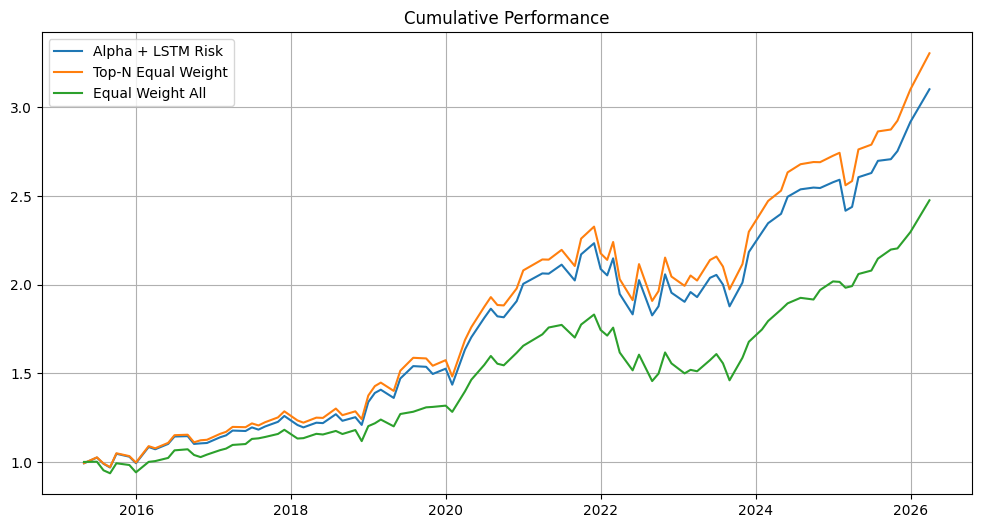

In [33]:
plot_df = results_df.copy()

plot_df["cum_strategy"] = (1 + plot_df["strategy_return"]).cumprod()
plot_df["cum_benchmark"] = (1 + plot_df["benchmark_return"]).cumprod()
plot_df["cum_equal_all"] = (1 + plot_df["equal_weight_all_return"]).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(plot_df["date"], plot_df["cum_strategy"], label="Alpha + LSTM Risk")
plt.plot(plot_df["date"], plot_df["cum_benchmark"], label="Top-N Equal Weight")
plt.plot(plot_df["date"], plot_df["cum_equal_all"], label="Equal Weight All")
plt.title("Cumulative Performance")
plt.legend()
plt.grid(True)
plt.show()



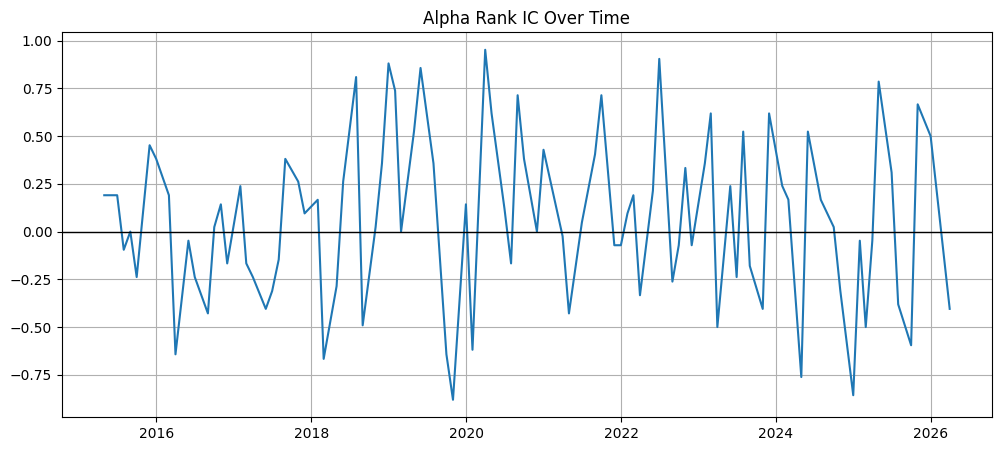

In [34]:
plt.figure(figsize=(12, 5))
plt.plot(plot_df["date"], plot_df["alpha_rank_ic"])
plt.axhline(0, color="black", linewidth=1)
plt.title("Alpha Rank IC Over Time")
plt.grid(True)
plt.show()


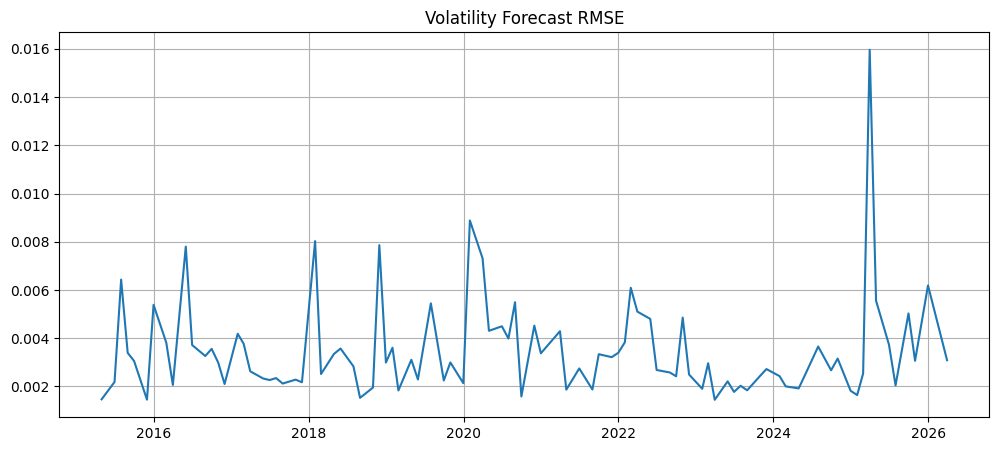

In [35]:

plt.figure(figsize=(12, 5))
plt.plot(plot_df["date"], plot_df["vol_rmse"])
plt.title("Volatility Forecast RMSE")
plt.grid(True)
plt.show()



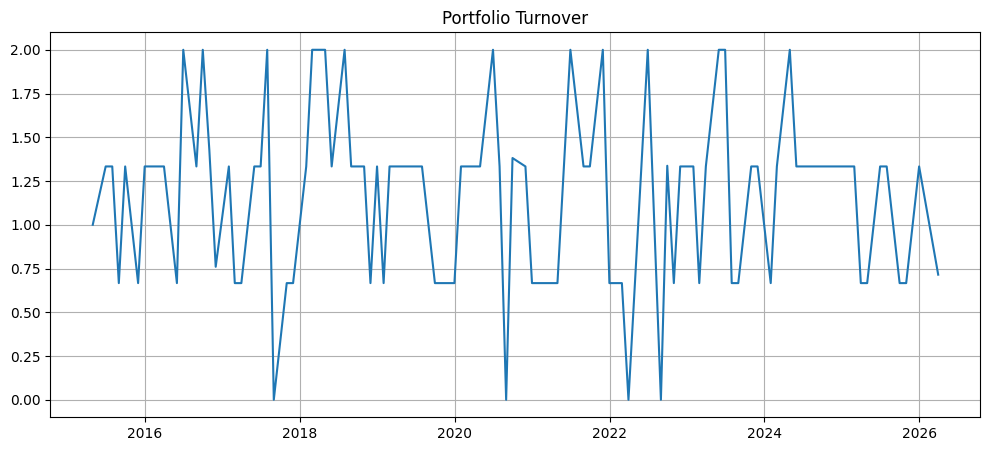

In [36]:
plt.figure(figsize=(12, 5))
plt.plot(plot_df["date"], plot_df["turnover"])
plt.title("Portfolio Turnover")
plt.grid(True)
plt.show()

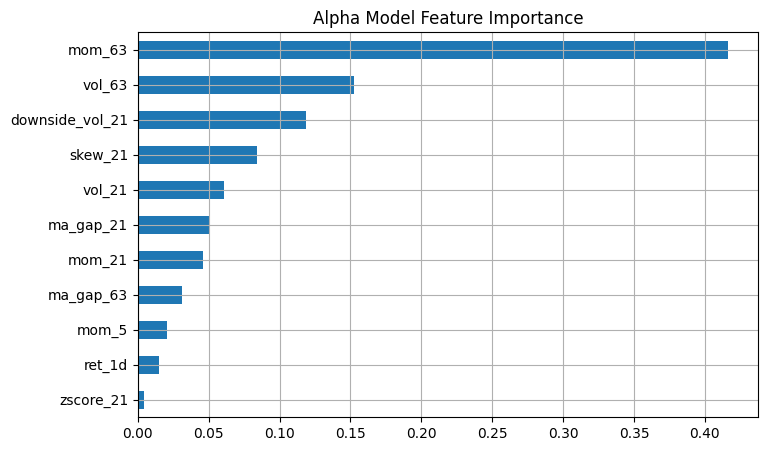

In [37]:
X_full = panel[feature_cols].values
y_full = panel["fwd_ret"].values

scaler_full = StandardScaler()
X_full_s = scaler_full.fit_transform(X_full)

alpha_final = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

alpha_final.fit(X_full_s, y_full)

importance = pd.Series(
    alpha_final.feature_importances_,
    index=feature_cols
).sort_values()

plt.figure(figsize=(8, 5))
importance.plot(kind="barh")
plt.title("Alpha Model Feature Importance")
plt.grid(True)
plt.show()